# Inspect county population: raw vs corrected

Browse the per-decade county population values from each source we feed into the unified panel:

- **NHGIS** — Census time-series 1790-2020, table A00 / Persons (`prep/input/nhgis0005_ts_nominal_county.csv`, long format).
- **HYDE** — gridded interpolation 1800-2000 (`prep/output/county_hyde_population.csv`).
- **Manual patch** — hand-curated Census values used to override NHGIS where its nominal historical boundary differs from the modern GEOID (NYC borough/Nassau split, Baltimore city/county split, DC consolidation, SF/Hamilton OH gaps). Defined in `prep/build_county_population.R`.
- **Final** — the unified value used downstream (`prep/output/county_population.csv`).

The final column also records `source` (`nhgis`, `hyde`, `manual`, or `missing`) so you can see which input won for each cell.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path('..').resolve()
PREP = REPO / 'prep'

def pad_geoid(s):
    return s.astype(str).str.zfill(5)

# NHGIS (long format: one row per county-decade; first two rows are headers/labels)
nhgis_raw = pd.read_csv(PREP / 'input' / 'nhgis0005_ts_nominal_county.csv', skiprows=2,
                        names=['GISJOIN','YEAR','STATE','STATEFP','STATENH',
                               'COUNTY','COUNTYFP','COUNTYNH','NAME','A00AA'],
                        low_memory=False)
nhgis_raw['GEOID'] = pad_geoid(nhgis_raw['STATEFP'].astype(str).str.zfill(2)
                               + nhgis_raw['COUNTYFP'].astype(str).str.zfill(3))
nhgis_raw['decade'] = pd.to_numeric(nhgis_raw['YEAR'], errors='coerce')
nhgis_raw['nhgis']  = pd.to_numeric(nhgis_raw['A00AA'], errors='coerce')
nhgis = (nhgis_raw[['GEOID', 'STATE', 'COUNTY', 'decade', 'nhgis']]
         .dropna(subset=['decade'])
         .astype({'decade': int}))
nhgis = nhgis[(nhgis['decade'] >= 1800) & (nhgis['decade'] <= 2000)]

# HYDE
hyde = pd.read_csv(PREP / 'output' / 'county_hyde_population.csv')
hyde['GEOID'] = pad_geoid(hyde['GEOID'])
hyde = hyde.rename(columns={'hyde_population': 'hyde'})[['GEOID', 'decade', 'hyde']]

# Final
final = pd.read_csv(PREP / 'output' / 'county_population.csv')
final['GEOID'] = pad_geoid(final['GEOID'])
final = final.rename(columns={'population': 'final', 'source': 'source'})

# Manual patches: derived as the cells where source == 'manual' in the final panel.
manual = final.loc[final['source'] == 'manual', ['GEOID', 'decade', 'final']].rename(columns={'final': 'manual'})

print(f'NHGIS rows: {len(nhgis):,}  HYDE rows: {len(hyde):,}  manual cells: {len(manual):,}  final rows: {len(final):,}')

NHGIS rows: 49,357  HYDE rows: 66,003  manual cells: 29  final rows: 66,003


In [2]:
# State+county lookup so you can paste a name instead of a GEOID.
names = nhgis[['GEOID', 'STATE', 'COUNTY']].drop_duplicates().reset_index(drop=True)
names['label'] = names['STATE'] + ' / ' + names['COUNTY']

def find_geoids(query):
    """Return rows whose STATE+COUNTY label contains `query` (case-insensitive)."""
    q = query.lower()
    return names[names['label'].str.lower().str.contains(q)].copy()

find_geoids('philadelphia')

,GEOID,STATE,COUNTY,label
265,42.0101.0,Pennsylvania,Philadelphia County,Pennsylvania / Philadelphia County


In [3]:
def inspect_county(geoid):
    """Side-by-side decade-level table for one GEOID."""
    geoid = str(geoid).zfill(5)
    label_row = names.loc[names['GEOID'] == geoid]
    label = label_row['label'].iloc[0] if len(label_row) else '(no NHGIS label)'
    print(f'{geoid}  {label}')
    df = (final.loc[final['GEOID'] == geoid, ['decade', 'final', 'source']]
             .merge(nhgis.loc[nhgis['GEOID'] == geoid, ['decade', 'nhgis']], on='decade', how='left')
             .merge(hyde.loc[hyde['GEOID'] == geoid, ['decade', 'hyde']], on='decade', how='left')
             .merge(manual.loc[manual['GEOID'] == geoid, ['decade', 'manual']], on='decade', how='left')
             .sort_values('decade')
             [['decade', 'nhgis', 'hyde', 'manual', 'final', 'source']])
    for c in ['nhgis', 'hyde', 'manual', 'final']:
        df[c] = pd.to_numeric(df[c], errors='coerce').round(0).astype('Int64')
    return df.reset_index(drop=True)

def plot_county(geoid):
    df = inspect_county(geoid)
    geoid_str = str(geoid).zfill(5)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    if df['nhgis'].notna().any():
        ax.plot(df['decade'], df['nhgis'], marker='o', label='NHGIS Census', color='#1b9e77')
    if df['hyde'].notna().any():
        ax.plot(df['decade'], df['hyde'], marker='s', label='HYDE gridded', color='#d95f02')
    if df['manual'].notna().any():
        ax.scatter(df['decade'], df['manual'], marker='*', s=180, label='Manual Census patch', color='#7570b3', zorder=5)
    ax.plot(df['decade'], df['final'], color='black', linewidth=1.2, alpha=0.6, label='Unified (used downstream)')
    label_row = names.loc[names['GEOID'] == geoid_str]
    label = label_row['label'].iloc[0] if len(label_row) else '(unknown)'
    ax.set_title(f'GEOID {geoid_str}  ({label})')
    ax.set_xlabel('Decade')
    ax.set_ylabel('Population')
    ax.set_yscale('log')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, linewidth=0.3, alpha=0.4)
    plt.tight_layout()
    plt.show()
    return df

## Spot-check the high-access treated counties

These are the counties whose population enters the elite-school treatment effect identification, so any pop error here directly biases the rate outcomes.

In [4]:
high_access = {
    '42101': 'Philadelphia PA — Central HS 1836 (g=1830)',
    '24510': 'Baltimore city MD — BCC 1839 (g=1830)',
    '06075': 'San Francisco CA — Lowell 1856 (g=1850)',
    '36061': 'New York (Manhattan) NY — Hunter 1869 (g=1860)',
    '11001': 'District of Columbia — Dunbar 1870 (g=1860)',
    '24005': 'Baltimore Co MD — McDonogh 1873 (g=1860)',
    '39061': 'Hamilton OH — Walnut Hills 1895 (g=1890)',
    '36047': 'Kings (Brooklyn) NY — Brooklyn Tech 1922 (g=1910)',
    '36005': 'Bronx NY — Bronx Sci 1938 (g=1930)',
}

for g, lbl in high_access.items():
    print(f'\n=== {g}  {lbl} ===')
    display(inspect_county(g))


=== 42101  Philadelphia PA — Central HS 1836 (g=1830) ===
42101  (no NHGIS label)


,decade,nhgis,hyde,manual,final,source
0,1800,<NA>,9866,<NA>,81009,nhgis
1,1810,<NA>,14678,<NA>,111210,nhgis
2,1820,<NA>,21001,<NA>,137097,nhgis
3,1830,<NA>,29791,<NA>,188797,nhgis
4,1840,<NA>,42001,<NA>,258037,nhgis
5,1850,<NA>,62037,<NA>,408762,nhgis
6,1860,<NA>,85816,<NA>,565529,nhgis
7,1870,<NA>,114249,<NA>,674022,nhgis
8,1880,<NA>,152153,<NA>,847170,nhgis
9,1890,<NA>,204173,<NA>,1046964,nhgis



=== 24510  Baltimore city MD — BCC 1839 (g=1830) ===
24510  (no NHGIS label)


,decade,nhgis,hyde,manual,final,source
0,1800,<NA>,10415,<NA>,26514,nhgis
1,1810,<NA>,12541,<NA>,46555,nhgis
2,1820,<NA>,14452,<NA>,62738,nhgis
3,1830,<NA>,17088,<NA>,80620,nhgis
4,1840,<NA>,19305,102313,102313,manual
5,1850,<NA>,25682,169054,169054,manual
6,1860,<NA>,32395,<NA>,212418,nhgis
7,1870,<NA>,39349,<NA>,39349,hyde
8,1880,<NA>,50242,<NA>,332313,nhgis
9,1890,<NA>,59611,<NA>,434439,nhgis



=== 06075  San Francisco CA — Lowell 1856 (g=1850) ===
06075  (no NHGIS label)


...

,decade,nhgis,hyde,manual,final,source
0,1800,<NA>,1517,14692,14692,manual
1,1810,<NA>,8086,<NA>,15258,nhgis
2,1820,<NA>,21336,<NA>,31764,nhgis
3,1830,<NA>,36188,<NA>,52317,nhgis
4,1840,<NA>,61480,<NA>,80145,nhgis
5,1850,<NA>,84047,<NA>,156844,nhgis
6,1860,<NA>,104029,<NA>,216410,nhgis
7,1870,<NA>,123904,<NA>,260370,nhgis
8,1880,<NA>,155281,<NA>,313374,nhgis
9,1890,<NA>,185896,<NA>,374573,nhgis



=== 36047  Kings (Brooklyn) NY — Brooklyn Tech 1922 (g=1910) ===
36047  (no NHGIS label)


,decade,nhgis,hyde,manual,final,source
0,1800,<NA>,9124,<NA>,5740,nhgis
1,1810,<NA>,16608,<NA>,8303,nhgis
2,1820,<NA>,26844,<NA>,11187,nhgis
3,1830,<NA>,42442,<NA>,20535,nhgis
4,1840,<NA>,60891,<NA>,47613,nhgis
5,1850,<NA>,88062,<NA>,138882,nhgis
6,1860,<NA>,124981,<NA>,279122,nhgis
7,1870,<NA>,159835,<NA>,419921,nhgis
8,1880,<NA>,208280,<NA>,599495,nhgis
9,1890,<NA>,275400,<NA>,838547,nhgis



=== 36005  Bronx NY — Bronx Sci 1938 (g=1930) ===
36005  (no NHGIS label)


,decade,nhgis,hyde,manual,final,source
0,1800,<NA>,5340,<NA>,5340,hyde
1,1810,<NA>,9662,<NA>,9662,hyde
2,1820,<NA>,15585,<NA>,15585,hyde
3,1830,<NA>,24627,<NA>,24627,hyde
4,1840,<NA>,35354,<NA>,35354,hyde
5,1850,<NA>,51188,<NA>,51188,hyde
6,1860,<NA>,72731,<NA>,72731,hyde
7,1870,<NA>,93109,<NA>,93109,hyde
8,1880,<NA>,121386,<NA>,121386,hyde
9,1890,<NA>,160539,<NA>,160539,hyde


42101  (no NHGIS label)


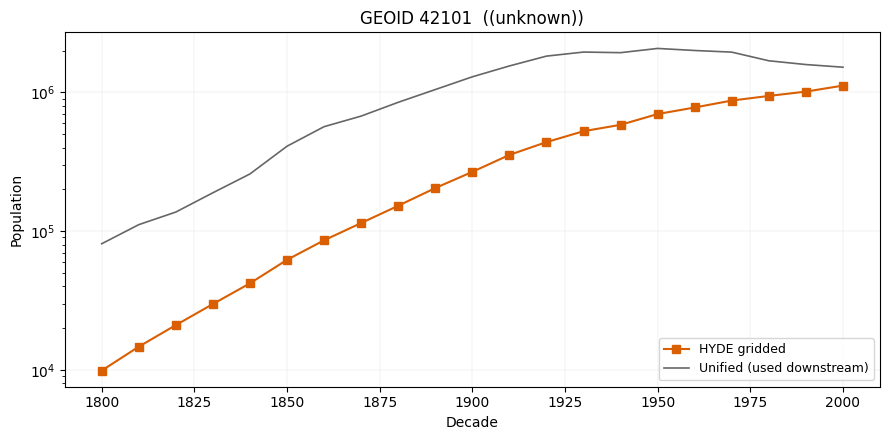

,decade,nhgis,hyde,manual,final,source
0,1800,<NA>,9866,<NA>,81009,nhgis
1,1810,<NA>,14678,<NA>,111210,nhgis
2,1820,<NA>,21001,<NA>,137097,nhgis
3,1830,<NA>,29791,<NA>,188797,nhgis
4,1840,<NA>,42001,<NA>,258037,nhgis
5,1850,<NA>,62037,<NA>,408762,nhgis
6,1860,<NA>,85816,<NA>,565529,nhgis
7,1870,<NA>,114249,<NA>,674022,nhgis
8,1880,<NA>,152153,<NA>,847170,nhgis
9,1890,<NA>,204173,<NA>,1046964,nhgis


In [5]:
plot_county('42101')

24510  (no NHGIS label)


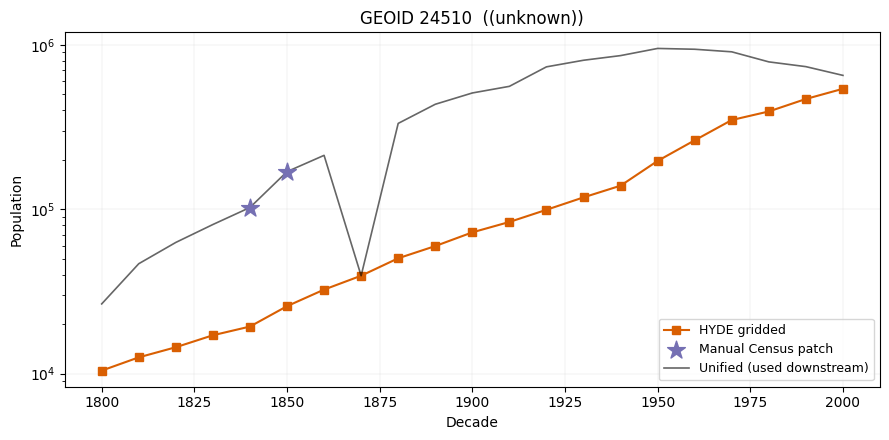

,decade,nhgis,hyde,manual,final,source
0,1800,<NA>,10415,<NA>,26514,nhgis
1,1810,<NA>,12541,<NA>,46555,nhgis
2,1820,<NA>,14452,<NA>,62738,nhgis
3,1830,<NA>,17088,<NA>,80620,nhgis
4,1840,<NA>,19305,102313,102313,manual
5,1850,<NA>,25682,169054,169054,manual
6,1860,<NA>,32395,<NA>,212418,nhgis
7,1870,<NA>,39349,<NA>,39349,hyde
8,1880,<NA>,50242,<NA>,332313,nhgis
9,1890,<NA>,59611,<NA>,434439,nhgis


In [6]:
plot_county('24510')

## Browse any county

Edit the cell below to look at any GEOID. Use `find_geoids('keyword')` to look up codes by name.

17031  (no NHGIS label)


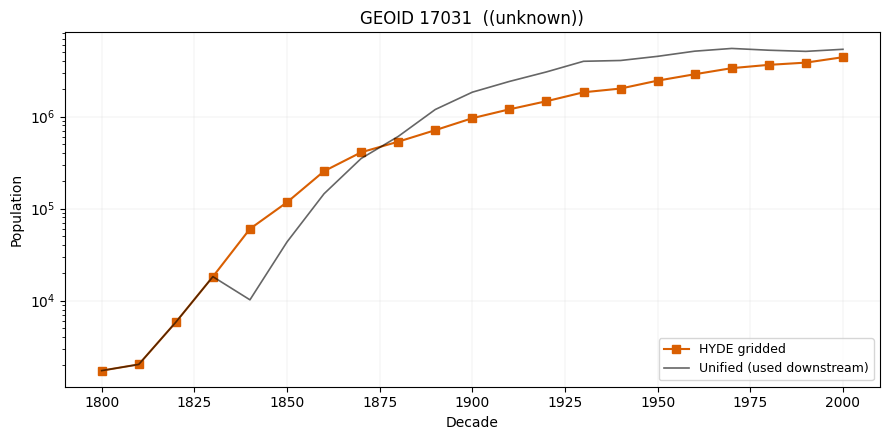

,decade,nhgis,hyde,manual,final,source
0,1800,<NA>,1736,<NA>,1736,hyde
1,1810,<NA>,2027,<NA>,2027,hyde
2,1820,<NA>,5829,<NA>,5829,hyde
3,1830,<NA>,18208,<NA>,18208,hyde
4,1840,<NA>,60206,<NA>,10201,nhgis
5,1850,<NA>,116994,<NA>,43385,nhgis
6,1860,<NA>,254980,<NA>,144954,nhgis
7,1870,<NA>,408515,<NA>,349966,nhgis
8,1880,<NA>,532932,<NA>,607524,nhgis
9,1890,<NA>,711040,<NA>,1191922,nhgis


In [7]:
# find_geoids('cook')
plot_county('17031')  # Cook County IL

## Diagnostics: where does HYDE diverge most from NHGIS?

For each county-decade where both sources are present, compute the ratio. Large divergences flag candidates for additional manual patches.

In [8]:
compare = (nhgis[['GEOID', 'decade', 'nhgis', 'STATE', 'COUNTY']]
             .merge(hyde, on=['GEOID', 'decade'], how='inner'))
compare = compare.dropna(subset=['nhgis', 'hyde'])
compare = compare[(compare['nhgis'] > 0) & (compare['hyde'] > 0)].copy()
compare['ratio_hyde_over_nhgis'] = compare['hyde'] / compare['nhgis']
compare.sort_values('ratio_hyde_over_nhgis').head(20)

,GEOID,decade,nhgis,STATE,COUNTY,hyde,ratio_hyde_over_nhgis


In [9]:
compare.sort_values('ratio_hyde_over_nhgis', ascending=False).head(20)

,GEOID,decade,nhgis,STATE,COUNTY,hyde,ratio_hyde_over_nhgis
